In [34]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns

pd.set_option('display.max_columns', None)

In [35]:
df_age = pd.read_csv('ig_follower_demographics_age.csv', index_col=0)
df_city = pd.read_csv('ig_follower_demographics_city.csv', index_col=0)
df_country = pd.read_csv('ig_follower_demographics_country.csv', index_col=0)
df_gender = pd.read_csv('ig_follower_demographics_gender.csv', index_col=0)
df_totals_by_window = pd.read_csv('ig_totals_by_window_long.csv')
df_totals_since_creation = pd.read_csv('ig_totals_since_creation.csv')



In [36]:
def eda(df, name):
    
    print(f"\n{'='*40}")
    print(f"EDA DEL DATAFRAME: {name.upper()}")
    print(f"{'='*40}\n")
    
    print("========== RESUMEN GENERAL ==========")
    print(f"Filas x Columnas (shape): {df.shape}")
    print("\nColumnas:")
    print(df.columns.tolist())

    print("\nDtypes:")
    print(df.dtypes)

    print("\nNulos por columna:")
    print(df.isnull().sum())

    print("\n========== DESCRIBE NUMÉRICO ==========")
    print(df.describe().T)

    print("\n========== DESCRIBE CATEGÓRICO (object/category) ==========")
    print(df.describe(include=["O"]).T)

    print("\n========== HEAD ==========")
    display(df.head())
    print("\n========== TAIL ==========")
    display(df.tail())
    print("\n========== SAMPLE ==========")
    display(df.sample())
    print("\n========== VALUE COUNTS (por columna categórica) ==========")
    col_categoricas =  df.select_dtypes(include=["object", "category"]).columns.tolist()

    for c in col_categoricas:
            print(f"\n--- {c} ---")
            print(df[c].value_counts)

    print("\n========== DUPLICADOS ==========")

    print(f"Duplicados: {df.duplicated().sum()}")

    print("\n========== HISTOGRAMAS NUMÉRICOS ==========")

    df.hist(bins=20, figsize=(25,25))
    plt.show()


EDA DEL DATAFRAME: TOTALS

========== RESUMEN GENERAL ==========
Filas x Columnas (shape): (210, 4)

Columnas:
['window_start', 'window_end', 'metric', 'value']

Dtypes:
window_start     object
window_end       object
metric           object
value           float64
dtype: object

Nulos por columna:
window_start     0
window_end       0
metric           0
value           21
dtype: int64

========== DESCRIBE NUMÉRICO ==========
       count       mean        std  min  25%  50%  75%    max
value  189.0  18.259259  56.131982  0.0  0.0  0.0  7.0  503.0

========== DESCRIBE CATEGÓRICO (object/category) ==========
             count unique             top freq
window_start   210     21      2024-06-25   10
window_end     210     21      2024-07-25   10
metric         210     10  website_clicks   21

========== HEAD ==========


,window_start,window_end,metric,value
0,2024-06-25,2024-07-25,website_clicks,266.0
1,2024-06-25,2024-07-25,profile_views,503.0
2,2024-06-25,2024-07-25,accounts_engaged,0.0
3,2024-06-25,2024-07-25,total_interactions,0.0
4,2024-06-25,2024-07-25,likes,0.0



========== TAIL ==========


,window_start,window_end,metric,value
205,2026-02-15,2026-02-27,comments,0.0
206,2026-02-15,2026-02-27,shares,0.0
207,2026-02-15,2026-02-27,saves,0.0
208,2026-02-15,2026-02-27,replies,0.0
209,2026-02-15,2026-02-27,follows_and_unfollows,NaN



========== SAMPLE ==========


,window_start,window_end,metric,value
146,2025-08-19,2025-09-18,shares,0.0



========== VALUE COUNTS (por columna categórica) ==========

--- window_start ---
<bound method IndexOpsMixin.value_counts of 0      2024-06-25
1      2024-06-25
2      2024-06-25
3      2024-06-25
4      2024-06-25
          ...    
205    2026-02-15
206    2026-02-15
207    2026-02-15
208    2026-02-15
209    2026-02-15
Name: window_start, Length: 210, dtype: object>

--- window_end ---
<bound method IndexOpsMixin.value_counts of 0      2024-07-25
1      2024-07-25
2      2024-07-25
3      2024-07-25
4      2024-07-25
          ...    
205    2026-02-27
206    2026-02-27
207    2026-02-27
208    2026-02-27
209    2026-02-27
Name: window_end, Length: 210, dtype: object>

--- metric ---
<bound method IndexOpsMixin.value_counts of 0             website_clicks
1              profile_views
2           accounts_engaged
3         total_interactions
4                      likes
               ...          
205                 comments
206                   shares
207                    save

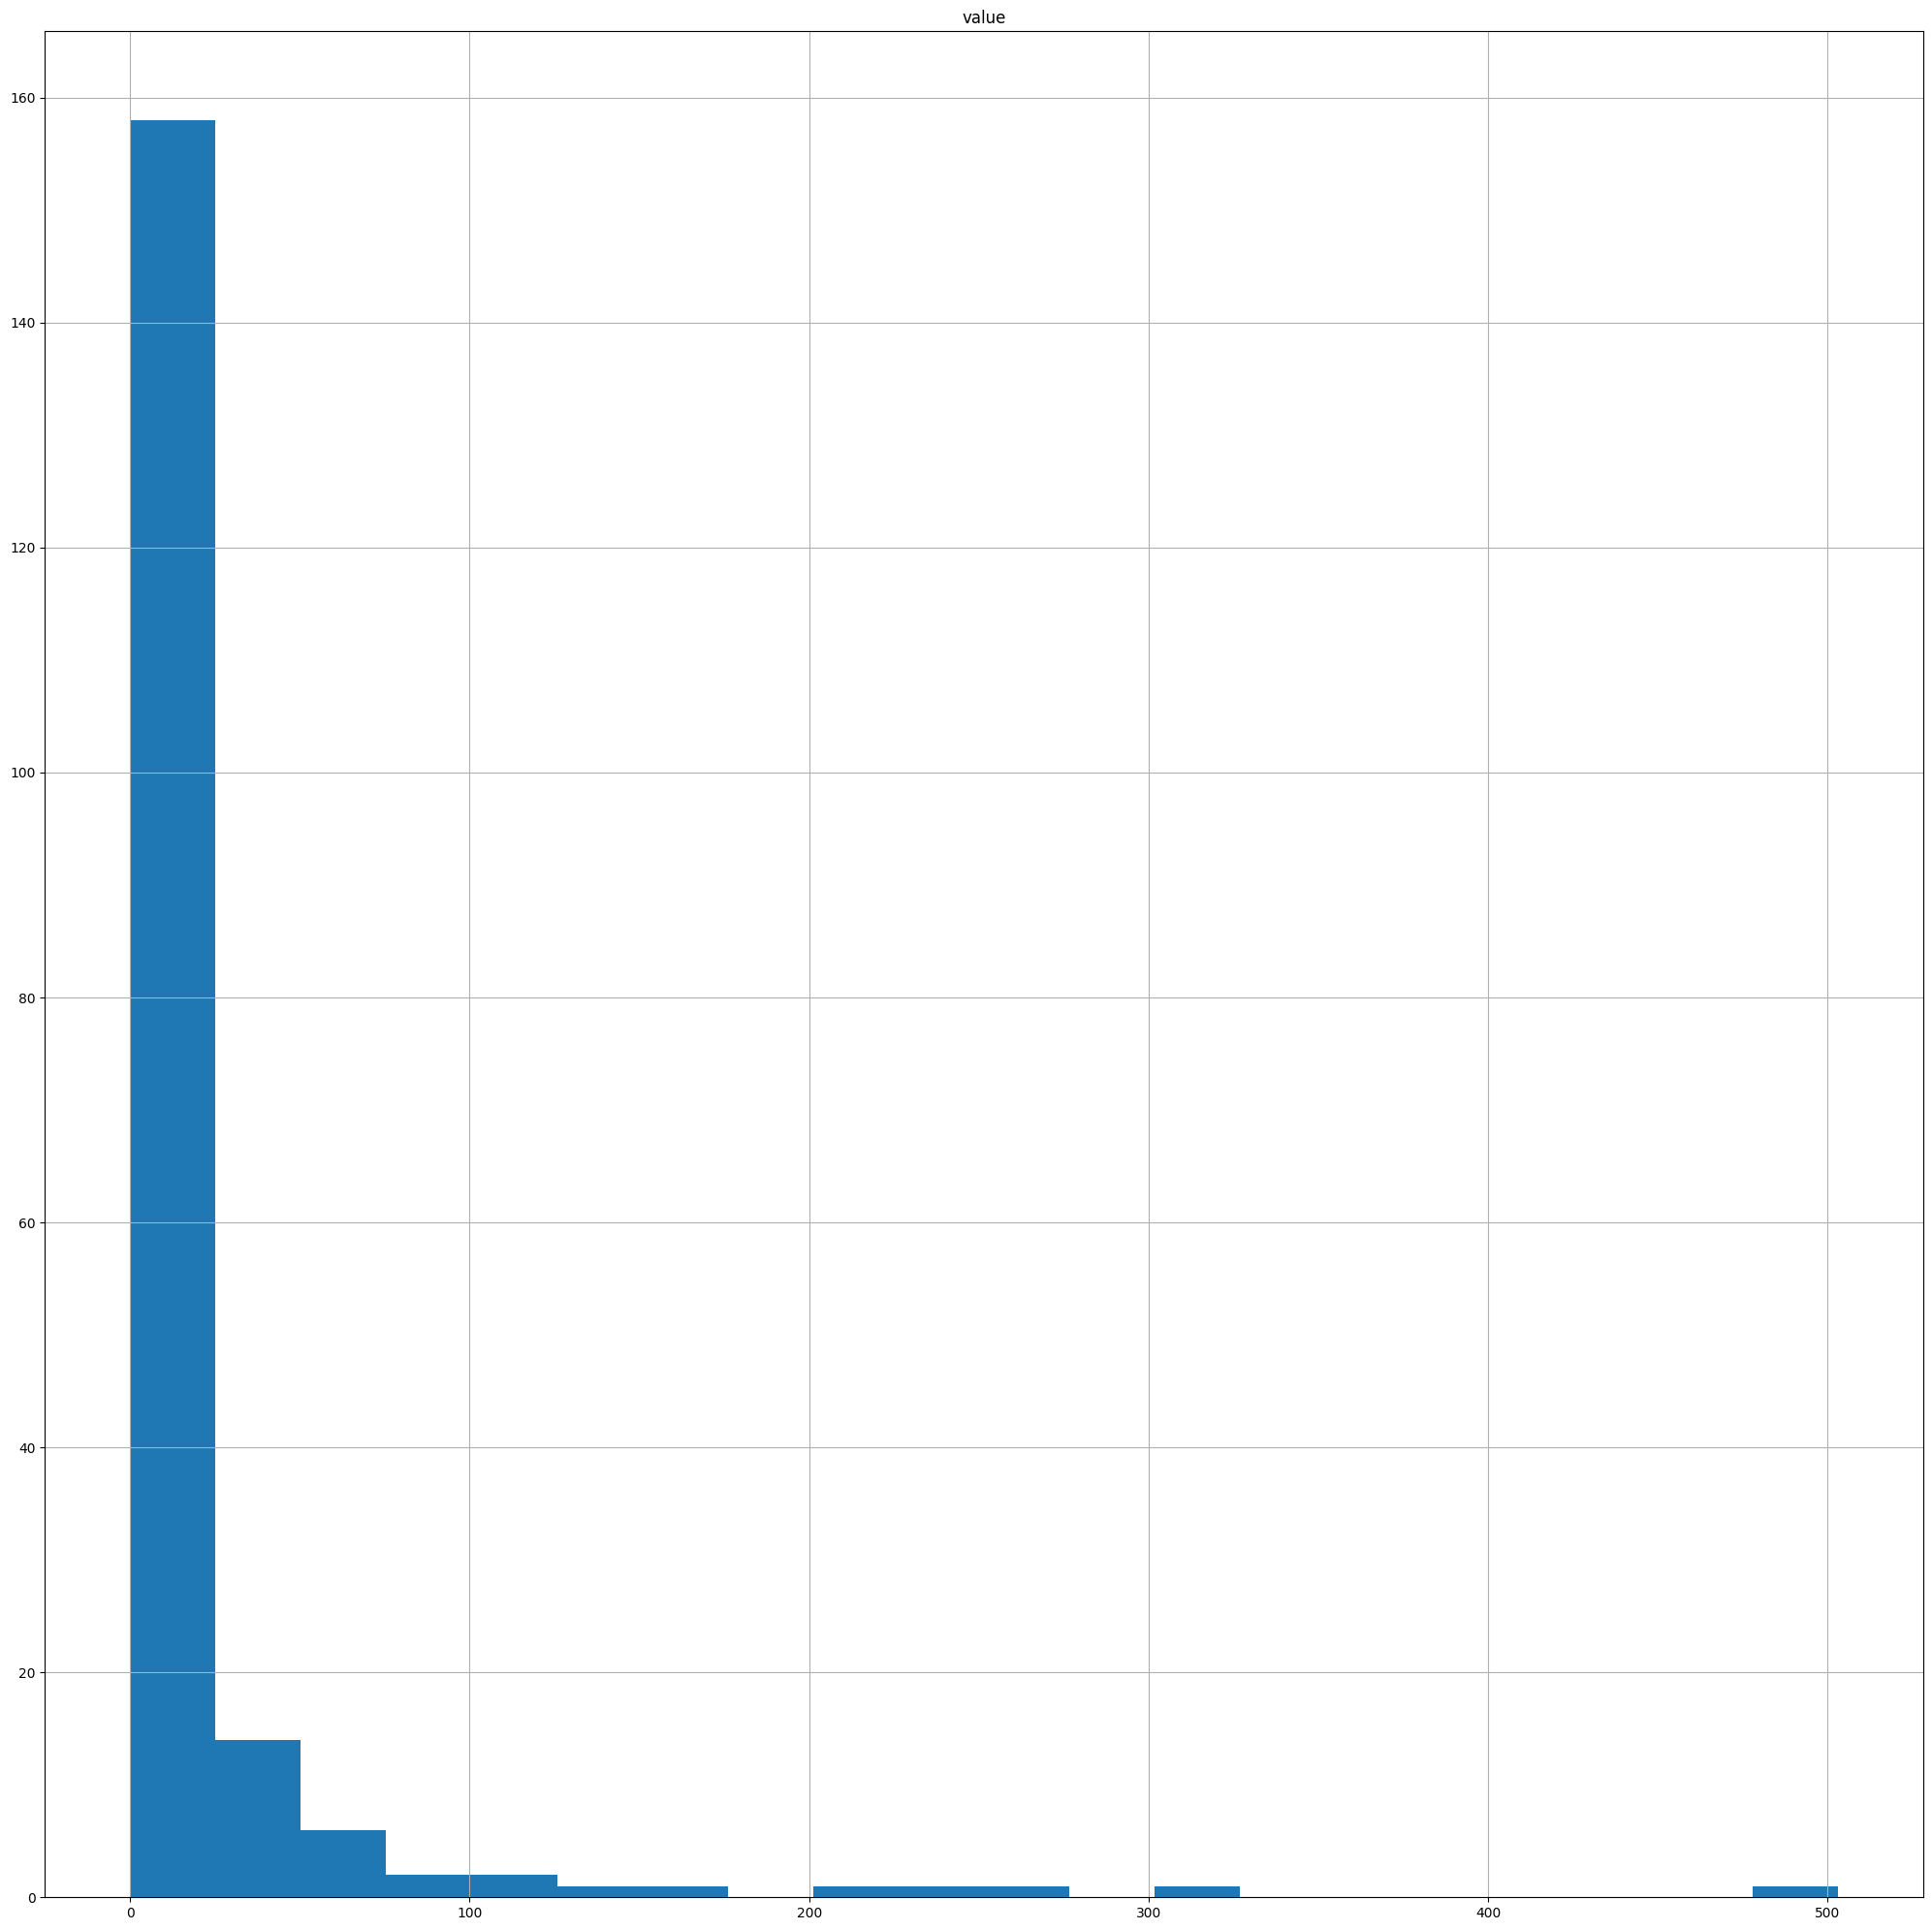

In [37]:
eda(df_totals_by_window, 'totals')

In [38]:
df_totals_by_window['value'] = df_totals_by_window['value'].fillna(df_totals_by_window['value'].median)

In [39]:
df_totals_by_window['value'] = (
    pd.to_numeric(df_totals_by_window['value'], errors='coerce')
      .round(0)
      .astype('Int64')
)

In [40]:
df_totals_by_window.dtypes

window_start    object
window_end      object
metric          object
value            Int64
dtype: object

In [41]:
import pandas as pd
import numpy as np
import csv
import re

def export_to_tableau(
    df: pd.DataFrame,
    path: str,
    sep: str = ";",
    encoding: str = "utf-8"
):
    """
    Limpia y exporta un DataFrame a CSV de forma segura para Tableau.

    - Elimina saltos de línea en textos (evita filas rotas)
    - Normaliza nombres de columnas
    - Controla nulos (NaN / NaT)
    - Fuerza quoting completo
    - Usa separador europeo (;)

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame limpio en pandas
    path : str
        Ruta de salida del CSV
    sep : str, optional
        Separador del CSV (default ';')
    encoding : str, optional
        Encoding del archivo (default 'utf-8')
    """

    df = df.copy()

    # 1️⃣ Normalizar nombres de columnas
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(" ", "_")
          .str.replace(r"[^a-z0-9_]", "", regex=True)
    )

    # 2️⃣ Limpiar saltos de línea y retornos en columnas de texto
    cols_texto = df.select_dtypes(include="object").columns
    df[cols_texto] = df[cols_texto].replace(
        {r"[\r\n]+": " "},
        regex=True
    )

    # 3️⃣ Convertir NaN / NaT a None (Tableau-friendly)
    df = df.replace({pd.NA: None, np.nan: None})

    # 4️⃣ Exportar CSV robusto
    df.to_csv(
        path,
        sep=sep,
        index=False,
        encoding=encoding,
        quoting=csv.QUOTE_ALL
    )

    print(f"✅ CSV exportado correctamente para Tableau: {path}")
    print(f"📊 Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

In [43]:
export_to_tableau(df_totals_by_window, 'total_metrics_by_window.csv')

✅ CSV exportado correctamente para Tableau: total_metrics_by_window.csv
📊 Filas: 210 | Columnas: 4
